# Extreme Correction 

In [1]:
import xarray as xr
import numpy as np

### Import Data

In [2]:
historical_dataset = xr.open_dataset("inputs/Wave_families_santona_daily.nc")
sampled_dataset = xr.open_dataset("inputs/simulated_waves_100years.nc").rename({"bulk_Hs": "Hs", "bulk_Tp": "Tp", "bulk_Dir": "Dir", "DWT": "bmus"})
sampled_dataset["bmus"] = sampled_dataset["bmus"] - 1 # Adjusting DWT index to start from 0

In [3]:
historical_dataset

<xarray.Dataset> Size: 935kB
Dimensions:      (time: 14610)
Coordinates:
  * time         (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
Data variables:
    sea_Hs       (time) float32 58kB ...
    sea_Tp       (time) float32 58kB ...
    sea_Dir      (time) float32 58kB ...
    swell_1_Hs   (time) float64 117kB ...
    swell_1_Tp   (time) float64 117kB ...
    swell_1_Dir  (time) float64 117kB ...
    Hs           (time) float32 58kB ...
    Tp           (time) float32 58kB ...
    Dir          (time) float32 58kB ...
    bmus         (time) int64 117kB ...

In [4]:
sampled_dataset

<xarray.Dataset> Size: 117MB
Dimensions:  (n_sim: 100, time: 36525)
Coordinates:
  * time     (time) datetime64[ns] 292kB 2000-01-01 2000-01-02 ... 2099-12-31
Dimensions without coordinates: n_sim
Data variables:
    bmus     (n_sim, time) int64 29MB 14 25 25 31 31 31 25 ... 21 23 23 23 23 17
    Hs       (n_sim, time) float64 29MB ...
    Tp       (n_sim, time) float64 29MB ...
    Dir      (n_sim, time) float64 29MB ...

### Apply correction in complete series

In [5]:
from bluemath_tk.distributions.extreme_correction import ExtremeCorrection

In [6]:
config = {
    "var": "Hs",
    "bmus": [False, ""],
    "join_sims": True,
    "folder": None,
}

pot_config = {
    "init_threshold": 0.01,
    "n0": 10,
    "min_peak_distance": 2,
    "sig_level": 0.05,
    "plot": False,
}

In [7]:
extr_corr = ExtremeCorrection(
    corr_config=config,
    pot_config=pot_config,
    method="pot" # "pot" for GPD or "am" for GEV
)

In [8]:
extr_corr.fit(data_hist=historical_dataset, plot_diagnostic=False)

In [9]:
sim_pit_data_corrected = extr_corr.transform(data_sim=sampled_dataset, prob="unif", random_state=0)

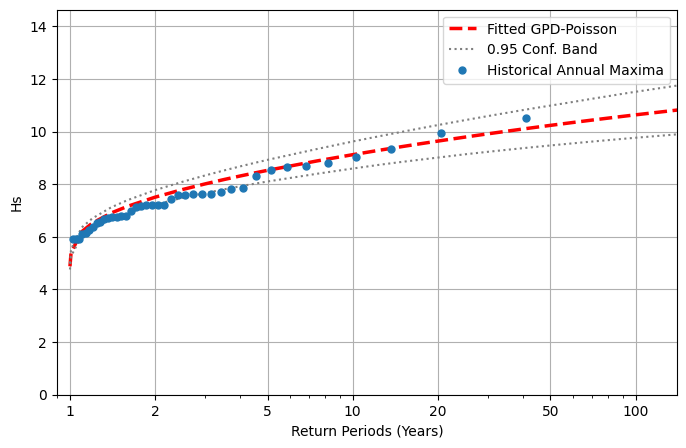

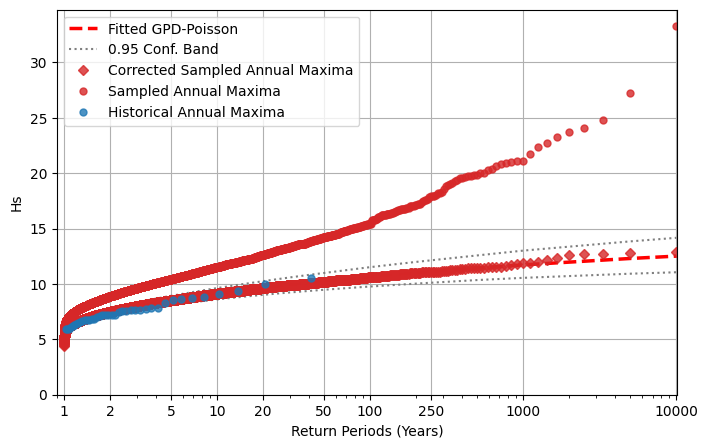

In [10]:
figs, axes = extr_corr.plot()

In [11]:
sim_pit_data_corrected

<xarray.Dataset> Size: 146MB
Dimensions:  (n_sim: 100, time: 36525)
Coordinates:
  * time     (time) datetime64[ns] 292kB 2000-01-01 2000-01-02 ... 2099-12-31
Dimensions without coordinates: n_sim
Data variables:
    bmus     (n_sim, time) int64 29MB 14 25 25 31 31 31 25 ... 21 23 23 23 23 17
    Hs       (n_sim, time) float64 29MB ...
    Tp       (n_sim, time) float64 29MB ...
    Dir      (n_sim, time) float64 29MB ...
    Hs_corr  (n_sim, time) float64 29MB 1.618 1.302 1.599 ... 2.251 2.177 0.9566

In [12]:
sim_pit_data_corrected = extr_corr.fit_transform(
    data_hist=historical_dataset,
    data_sim=sampled_dataset,
    prob="unif",
    plot_diagnostic=False
)

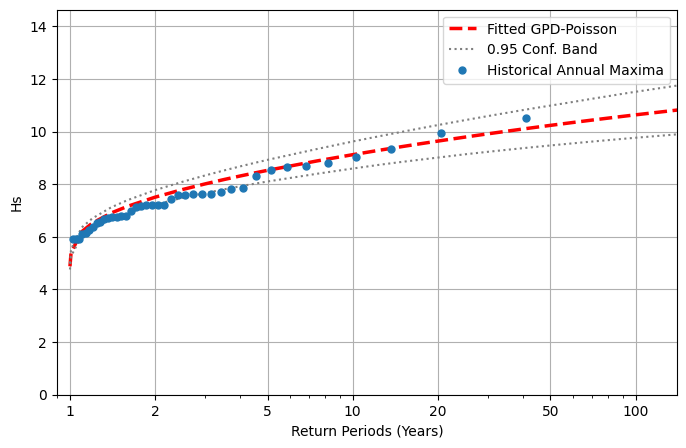

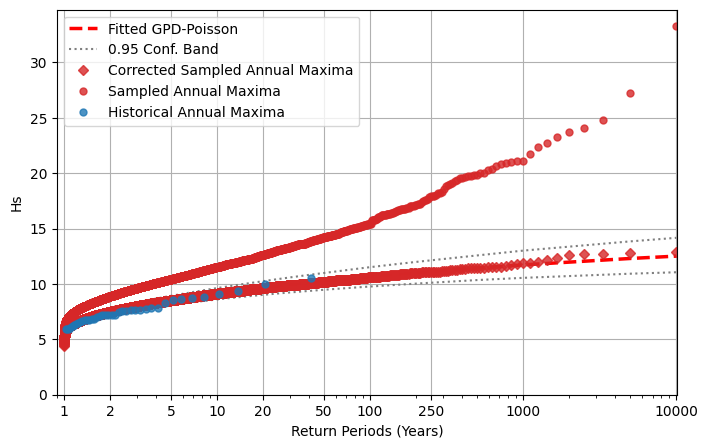

In [13]:
figs, axes = extr_corr.plot()

### Apply correction by Weather Types

In [14]:
config = {
    "var": "Hs",
    "bmus": [False, ""],
    "join_sims": True,
    "folder": None,
}

pot_config = {
    "init_threshold": 0.01,
    "n0": 10,
    "min_peak_distance": 2,
    "sig_level": 0.05,
    "plot": False,
}

In [15]:
extr_corr = ExtremeCorrection(
    corr_config=config,
    pot_config=pot_config,
    method="pot" # "pot" for GPD or "am" for GEV
)

In [16]:
final_simulated_data = sampled_dataset.copy()
final_simulated_data["Hs_corr"] = xr.zeros_like(final_simulated_data["Hs"])


for wt in np.unique(historical_dataset.get("bmus").values):
# for wt in [0]:

    print(f"Applying correction for Weather Type: {wt}")
    hist_wt = historical_dataset.copy()
    sim_wt = sampled_dataset.copy()

    hist_hs_aux = np.zeros_like(historical_dataset["Hs"].values)
    hist_hs_aux[np.where(historical_dataset.get("bmus") == wt)[0]] = historical_dataset.isel(time=np.where(historical_dataset.get("bmus") == wt)[0])["Hs"].values
    hist_wt["Hs"].values = hist_hs_aux
    
    sim_hs_aux = np.zeros_like(sampled_dataset["Hs"])
    for sim in sampled_dataset.n_sim.values:
        sim_hs_aux[sim,np.where(sampled_dataset.get("bmus").isel(n_sim=sim) == wt)[0]] = sampled_dataset.isel(time=np.where(sampled_dataset.get("bmus").isel(n_sim=sim) == wt)[0], n_sim=sim)["Hs"].values
    sim_wt["Hs"].values = sim_hs_aux


    corr_ouput = extr_corr.fit_transform(
        data_hist=hist_wt,
        data_sim=sim_wt,
        prob="unif",
        plot_diagnostic=False,
    )
    
    final_simulated_data["Hs_corr"].values = final_simulated_data["Hs_corr"].values + corr_ouput["Hs_corr"].values

Applying correction for Weather Type: 0
Applying correction for Weather Type: 1
Applying correction for Weather Type: 2
Applying correction for Weather Type: 3
Applying correction for Weather Type: 4
Applying correction for Weather Type: 5
Applying correction for Weather Type: 6
Applying correction for Weather Type: 7
Applying correction for Weather Type: 8
Applying correction for Weather Type: 9
Applying correction for Weather Type: 10
Applying correction for Weather Type: 11
Applying correction for Weather Type: 12
Applying correction for Weather Type: 13
Applying correction for Weather Type: 14
Applying correction for Weather Type: 15
Applying correction for Weather Type: 16
Applying correction for Weather Type: 17
Applying correction for Weather Type: 18
Applying correction for Weather Type: 19
Applying correction for Weather Type: 20
Applying correction for Weather Type: 21
Applying correction for Weather Type: 22
Applying correction for Weather Type: 23
Applying correction for We

### Return Period plot

In [17]:
import matplotlib.pyplot as plt

In [18]:
# Annual Maxima
am_hist = historical_dataset["Hs"].groupby("time.year").max()
am_corrected = final_simulated_data["Hs_corr"].groupby("time.year").max()
am_uncorrected = final_simulated_data["Hs"].groupby("time.year").max()

# Historical AM Return Periods
n_year = extr_corr.am_data.shape[0]
ecdf_am_probs_hist = np.arange(1, n_year + 1) / (n_year + 1)
T_annmax = 1 / (1 - ecdf_am_probs_hist)

# Simulated AM Return Periods
n_year_sim = am_corrected.shape[1]
ecdf_annmax_probs_sim = np.arange(1, n_year_sim + 1) / (n_year_sim + 1)
T_annmax_sim = 1 / (1 - ecdf_annmax_probs_sim)


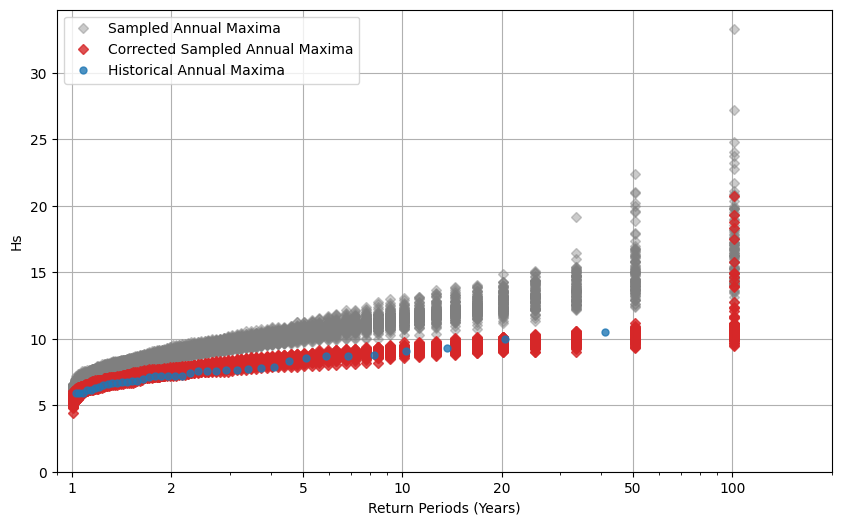

In [19]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)


# No-Corrected Sampled AM values
ax.semilogx(
    T_annmax_sim,
    np.sort(am_uncorrected.isel(n_sim=0).values),
    color="tab:gray",
    linewidth=0,
    marker="D",
    markersize=5,
    alpha=0.4,
    label="Sampled Annual Maxima",
)
for sim in final_simulated_data.n_sim.values[1:]:
    ax.semilogx(
        T_annmax_sim,
        np.sort(am_uncorrected.isel(n_sim=sim).values),
        color="tab:gray",
        linewidth=0,
        marker="D",
        markersize=5,
        alpha=0.4
    )


# Corrected Sampled AM values
ax.semilogx(
        T_annmax_sim,
        np.sort(am_corrected.isel(n_sim=0).values),
        color="tab:red",
        linewidth=0,
        marker="D",
        markersize=5,
        alpha=0.8,
        label="Corrected Sampled Annual Maxima",
    )
for sim in final_simulated_data.n_sim.values[1:]:
    ax.semilogx(
        T_annmax_sim,
        np.sort(am_corrected.isel(n_sim=sim).values),
        color="tab:red",
        linewidth=0,
        marker="D",
        markersize=5,
        alpha=0.8
    )


# Historical AM values
ax.semilogx(
    T_annmax,
    np.sort(am_hist),
    color="tab:blue",
    linewidth=0,
    marker="o",
    markersize=5,
    alpha=0.8,
    label="Historical Annual Maxima",
)

ax.set_xlabel("Return Periods (Years)")
ax.set_ylabel(f"{extr_corr.var}")
ax.set_xscale("log")
ax.set_xticks([1, 2, 5, 10, 20, 50, 100, 250, 1000, 10000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlim(left=0.9, right=n_year_sim + 100)
ax.set_ylim(bottom=0)
ax.legend(loc="best")
ax.grid()